# Module import


In [ ]:
# Import Libraries

import numpy as np # linear algebra
import pandas as pd # for data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for data visulaization
from sklearn.preprocessing import MinMaxScaler


from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
!pip install catboost
import catboost
import xgboost
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Data load - 아래는 수상작 팀의 주석


이번 과제에서 사용된 데이터셋은 미국에서 전이성 삼중 음성 유방암(metastatic triple negative breast cancer) 진단을 받은 환자들의 건강 관련 정보를 포함하고 있습니다.

이 데이터셋은 환자들의 거주지 위치를 기반으로 한 추가적인 사회경제적 정보를 얻기 위해, 미국 우편번호(Zip Code) 데이터베이스로 보강되었습니다. 이 데이터베이스는 미국 우정청(U.S. Postal Service™), 미국 인구조사국(U.S. Census Bureau), 미국 국립기상청(National Weather Service), 미국 지역사회조사(American Community Survey), 미국 국세청(IRS) 등의 신뢰할 수 있는 기관으로부터 수집된 정보를 기반으로 구축된 것입니다.

또한, 데이터는 같은 우편번호 수준에서 NASA/Columbia University의 독성학 데이터로 추가 보강되어, 건강 결과와 유독성 대기 조건 사이의 관계를 탐색할 수 있도록 구성되었습니다.

In [ ]:
# 데이터 로드

df = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/training.csv")
tdf = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/test.csv")
ss = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/sample_submission.csv")

# 원본 데이터
df_raw = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/training.csv")
tdf_raw = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/test.csv")
ss_raw = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/sample_submission.csv")

# 수상팀 데이터
df_ori = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/training.csv").drop("breast_cancer_diagnosis_code",axis=1)
tdf_ori = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/test.csv").drop("breast_cancer_diagnosis_code",axis=1)
ss_ori = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/sample_submission.csv")


In [ ]:
df

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,C50411,Malig neoplm of upper-outer quadrant of right ...,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,C50112,Malignant neoplasm of central portion of left ...,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,C50212,Malig neoplasm of upper-inner quadrant of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12901,674178,White,NaN,OH,436,50,F,32.11,C50411,Malig neoplm of upper-outer quadrant of right ...,...,17.400000,23.600000,0.864706,19.841176,6.300000,6.247059,38.753055,8.068682,21.140731,1
12902,452909,NaN,COMMERCIAL,CA,945,50,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,11.243210,7.837037,5.411250,34.700000,3.845679,5.671605,36.469947,6.265266,10.728732,1
12903,357486,NaN,COMMERCIAL,CA,926,61,F,29.24,C50912,Malignant neoplasm of unspecified site of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,1
12904,935417,NaN,NaN,NY,112,37,F,31.00,1749,"Malignant neoplasm of breast (female), unspeci...",...,10.194737,18.642105,14.173684,42.502632,6.392105,1.755263,37.722740,7.879795,27.496367,0


In [ ]:
tdf

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,hispanic,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02
0,573710,White,MEDICAID,IN,467,54,F,NaN,C50412,Malig neoplasm of upper-outer quadrant of left...,...,3.564516,13.996774,7.985484,0.969355,24.955357,10.838710,8.080645,38.724876,7.947165,11.157161
1,593679,NaN,COMMERCIAL,FL,337,52,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,10.261538,16.020513,13.602564,2.836842,23.952632,10.579487,9.302564,36.918257,7.838973,13.599985
2,184532,Hispanic,MEDICAID,CA,917,61,F,NaN,C50911,Malignant neoplasm of unsp site of right femal...,...,47.726087,9.895652,10.515217,12.745652,32.530435,7.263043,3.810870,47.310325,9.595719,20.084231
3,447383,Hispanic,MEDICARE ADVANTAGE,CA,917,64,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,47.726087,9.895652,10.515217,12.745652,32.530435,7.263043,3.810870,47.310325,9.595719,20.084231
4,687972,Black,NaN,CA,900,40,F,23.00,C50412,Malig neoplasm of upper-outer quadrant of left...,...,45.526154,11.901538,20.760000,14.737500,30.709375,10.341538,3.030769,41.186992,11.166898,21.644261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,977076,White,NaN,KY,404,63,F,29.60,C50411,Malig neoplm of upper-outer quadrant of right ...,...,1.243478,20.404348,20.813636,0.350000,30.152174,6.473913,5.908696,39.947326,7.622672,9.154618
5788,922960,White,NaN,IA,507,69,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,6.175000,16.675000,15.900000,2.800000,16.800000,5.475000,6.875000,35.825340,7.610534,9.712786
5789,759690,NaN,MEDICARE ADVANTAGE,WA,980,84,F,28.28,C50411,Malig neoplm of upper-outer quadrant of right ...,...,9.511321,9.752830,6.432075,5.094340,31.275472,5.309434,5.807547,36.618644,4.939852,23.393650
5790,911717,NaN,COMMERCIAL,OK,740,58,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,4.374627,15.544776,16.603030,0.513636,25.877273,14.926866,7.600000,39.832235,8.030925,9.769358


In [ ]:
ss #?

,patient_id,DiagPeriodL90D
0,573710,0.5
1,593679,0.5
2,184532,0.5
3,447383,0.5
4,687972,0.5
...,...,...
5787,977076,0.5
5788,922960,0.5
5789,759690,0.5
5790,911717,0.5


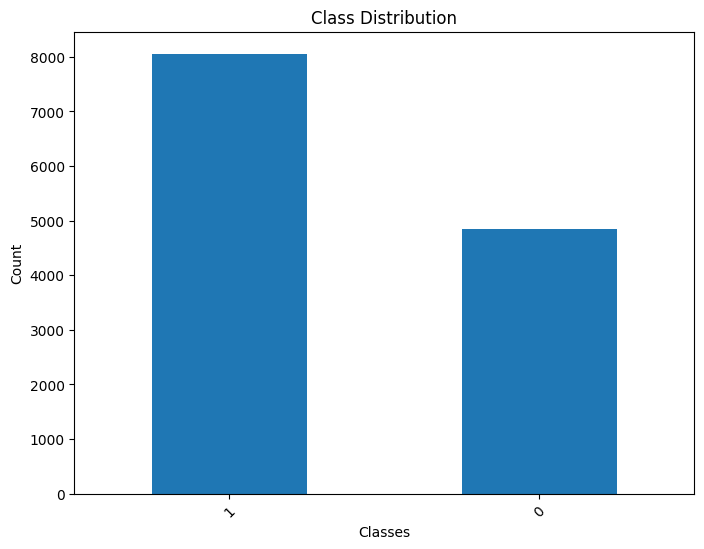

In [ ]:
target = "DiagPeriodL90D"

# Count the occurrences of each class
class_counts = df[target].value_counts()

# Plot the class distribution
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 데이터 기본 전처리 (결측치)

### 데이터 확인

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12906 entries, 0 to 12905
Data columns (total 83 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   patient_id                             12906 non-null  int64  
 1   patient_race                           6521 non-null   object 
 2   payer_type                             11103 non-null  object 
 3   patient_state                          12855 non-null  object 
 4   patient_zip3                           12906 non-null  int64  
 5   patient_age                            12906 non-null  int64  
 6   patient_gender                         12906 non-null  object 
 7   bmi                                    3941 non-null   float64
 8   breast_cancer_diagnosis_code           12906 non-null  object 
 9   breast_cancer_diagnosis_desc           12906 non-null  object 
 10  metastatic_cancer_diagnosis_code       12906 non-null  object 
 11  me

In [ ]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 82 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   patient_id                             5792 non-null   int64  
 1   patient_race                           2891 non-null   object 
 2   payer_type                             5032 non-null   object 
 3   patient_state                          5771 non-null   object 
 4   patient_zip3                           5792 non-null   int64  
 5   patient_age                            5792 non-null   int64  
 6   patient_gender                         5792 non-null   object 
 7   bmi                                    1777 non-null   float64
 8   breast_cancer_diagnosis_code           5792 non-null   object 
 9   breast_cancer_diagnosis_desc           5792 non-null   object 
 10  metastatic_cancer_diagnosis_code       5792 non-null   object 
 11  meta

### 환경변수 생성 시 필요한 칼럼 결측치 처리 (N02, PM25, commute_time)

In [ ]:
# zip3 기반 결측치 처리 시도

def fill_missing_by_group_unique_value(df, column_name):
    group_col = 'patient_zip3'
    grouped = df.groupby(group_col)

    # 1. 고유값 개수 확인
    unique_value_check = grouped[column_name].nunique(dropna=True)
    all_one_unique = (unique_value_check == 1).all()

    if all_one_unique:
        print(f"✅ 모든 그룹에 대해 '{column_name}' 컬럼의 고유값이 하나씩 존재합니다.")
    else:
        print(f"⚠️ 고유값이 하나가 아닌 그룹 및 그 고유값들:")
        not_one_unique_groups = unique_value_check[unique_value_check != 1].index
        for g in not_one_unique_groups:
            unique_vals = df[df[group_col] == g][column_name].dropna().unique()
            print(f"  - 그룹 {g}: 고유값들 = {unique_vals}")

    # 2. 결측치가 있는 그룹 찾기
    missing_per_group = grouped[column_name].apply(lambda x: x.isna().any())
    groups_with_missing = missing_per_group[missing_per_group].index.tolist()

    if groups_with_missing:
        print(f"\n📌 '{column_name}' 컬럼에 결측치가 있는 그룹 (총 {len(groups_with_missing)}개):")
        for g in groups_with_missing:
            print(f"\n- 그룹 {g} (결측치 포함된 데이터):")
            print(df.loc[df[group_col] == g, [group_col, column_name]])
    else:
        print(f"\n✅ '{column_name}' 컬럼에는 결측치가 없습니다.")
        return df

    # 3. 결측치 채우기
    def fill_group(group):
        if group[column_name].isna().any():
            unique_vals = group[column_name].dropna().unique()
            if len(unique_vals) == 1:
                group[column_name] = group[column_name].fillna(unique_vals[0])
        return group

    df_filled = grouped.apply(fill_group).reset_index(drop=True)

    # 4. 결측치 처리 후 확인
    remaining_missing_df = df_filled[df_filled[column_name].isna()]
    remaining_missing = remaining_missing_df.shape[0]

    if remaining_missing == 0:
        print(f"\n🎉 '{column_name}' 컬럼의 결측치가 모두 성공적으로 채워졌습니다!")
    else:
        print(f"\n❗ 아직 {remaining_missing}개의 결측치가 남아 있으며, 해당 데이터는 아래와 같습니다:")
        print(remaining_missing_df[[group_col, column_name]])

    return df_filled


df = fill_missing_by_group_unique_value(df, 'N02') # N02 칼럼의 결측치를 zip3 그룹별로 확인하여 대체 시도
print("\n================================================\n")
df = fill_missing_by_group_unique_value(df, 'PM25') # PM25 칼럼의 결측치를 zip3 그룹별로 확인하여 대체 시도
print("\n================================================\n")
df = fill_missing_by_group_unique_value(df, 'commute_time') # commute_time 칼럼의 결측치를 zip3 그룹별로 확인하여 대체 시도

⚠️ 고유값이 하나가 아닌 그룹 및 그 고유값들:
  - 그룹 967: 고유값들 = []
  - 그룹 968: 고유값들 = []
  - 그룹 995: 고유값들 = []
  - 그룹 996: 고유값들 = []
  - 그룹 998: 고유값들 = []
  - 그룹 999: 고유값들 = []

📌 'N02' 컬럼에 결측치가 있는 그룹 (총 6개):

- 그룹 967 (결측치 포함된 데이터):
       patient_zip3  N02
155             967  NaN
2699            967  NaN
3674            967  NaN
4716            967  NaN
5022            967  NaN
5053            967  NaN
6272            967  NaN
7982            967  NaN
8379            967  NaN
8840            967  NaN
10332           967  NaN
12092           967  NaN

- 그룹 968 (결측치 포함된 데이터):
       patient_zip3  N02
638             968  NaN
1108            968  NaN
1328            968  NaN
4475            968  NaN
5222            968  NaN
6059            968  NaN
6495            968  NaN
7220            968  NaN
8684            968  NaN
11839           968  NaN
12561           968  NaN

- 그룹 995 (결측치 포함된 데이터):
      patient_zip3  N02
2353           995  NaN
7310           995  NaN

- 그룹 996 (결측치 포함된 데이터):
      patie

In [ ]:
tdf = fill_missing_by_group_unique_value(tdf, 'N02') # N02 칼럼의 결측치를 zip3 그룹별로 확인하여 대체 시도
print("\n================================================\n")
tdf = fill_missing_by_group_unique_value(tdf, 'PM25') # PM25 칼럼의 결측치를 zip3 그룹별로 확인하여 대체 시도
print("\n================================================\n")
tdf = fill_missing_by_group_unique_value(tdf, 'commute_time') # commute_time 칼럼의 결측치를 zip3 그룹별로 확인하여 대체 시도

⚠️ 고유값이 하나가 아닌 그룹 및 그 고유값들:
  - 그룹 967: 고유값들 = []
  - 그룹 968: 고유값들 = []
  - 그룹 996: 고유값들 = []

📌 'N02' 컬럼에 결측치가 있는 그룹 (총 3개):

- 그룹 967 (결측치 포함된 데이터):
      patient_zip3  N02
182            967  NaN
803            967  NaN
1683           967  NaN
1998           967  NaN
2266           967  NaN
2518           967  NaN
3229           967  NaN
3587           967  NaN
3873           967  NaN
4511           967  NaN
4517           967  NaN

- 그룹 968 (결측치 포함된 데이터):
      patient_zip3  N02
1000           968  NaN
1412           968  NaN

- 그룹 996 (결측치 포함된 데이터):
      patient_zip3  N02
3083           996  NaN

❗ 아직 14개의 결측치가 남아 있으며, 해당 데이터는 아래와 같습니다:
      patient_zip3  N02
5652           967  NaN
5653           967  NaN
5654           967  NaN
5655           967  NaN
5656           967  NaN
5657           967  NaN
5658           967  NaN
5659           967  NaN
5660           967  NaN
5661           967  NaN
5662           967  NaN
5663           968  NaN
5664           968  NaN
5791         

-> zip3로 그룹화하였을 때, 각 그룹의 모든 값이 결측치여서 이를 대체할 수 있는 대표값 존재 X
\
\
**=> 그러므로 결측치 냅두기**

In [ ]:
# 또는 결측치 대체

# 개선안 케이스 별로 생성

In [ ]:
# 시나리오 별 데이터 프레임 생성

df1 = df.copy()
tdf1 = tdf.copy()

df2 = df.copy()
tdf2 = tdf.copy()

df3 = df.copy()
tdf3 = tdf.copy()

df4 = df.copy()
tdf4 = tdf.copy()

# df4,5,6은 이어지므로 코드 직전에 포함돼있음

### **df1** : 기대효과 1. meta_code4 생성

In [ ]:
# meta 칼럼에서 5자리 값을 4자리로 변환
df1['meta_code4'] = df1['metastatic_cancer_diagnosis_code'].astype(str).apply(lambda x: x[:4] if len(x) >= 5 else x)
tdf1['meta_code4'] = tdf1['metastatic_cancer_diagnosis_code'].astype(str).apply(lambda x: x[:4] if len(x) >= 5 else x)

# 결과 확인
print(df1['meta_code4'].nunique())
print(df1['meta_code4'].value_counts())

27
meta_code4
C773    7052
C795    1874
C798     823
C779     764
C780     636
C787     362
C793     289
C799     282
C792     166
C771     156
C770     126
C782      81
C778      77
C786      43
C781      31
C772      27
C794      22
C796      20
C785      16
C788      14
C775      13
C797      10
C791       7
C784       6
C790       4
C774       3
C783       2
Name: count, dtype: int64


### **df2** : 기대효과 3. 새로운 환경변수 (N02 x PM25 x commute_time)

In [ ]:
# 세 칼럼을 스케일링 할 때 df2와 인덱스를 맞춰서 스케일링
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df2[['N02', 'PM25', 'commute_time']])
df2_scaled = pd.DataFrame(scaled_values, columns=['N02_scaled', 'PM25_scaled', 'commute_scaled'], index=df2.index)

# 파생변수 생성 (인덱스 일치하므로 문제 없음)
df2['NO2xPM25xcommute_scaled'] = (
    df2_scaled['N02_scaled'] * df2_scaled['PM25_scaled'] * df2_scaled['commute_scaled']
)

df2

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D,NO2xPM25xcommute_scaled
0,418562,White,MEDICAID,NY,101,68,F,NaN,C50511,Malig neoplm of lower-outer quadrant of right ...,...,4.150000,1.150000,27.850000,5.400000,1.200000,39.476275,4.178836,4.131900,1,0.003733
1,496546,NaN,MEDICARE ADVANTAGE,NY,101,71,F,NaN,C50411,Malig neoplm of upper-outer quadrant of right ...,...,4.150000,1.150000,27.850000,5.400000,1.200000,39.476275,4.178836,4.131900,1,0.003733
2,773832,NaN,NaN,NY,103,40,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,10.925000,6.441667,44.791667,4.583333,3.283333,38.718935,7.299229,22.112395,0,0.334505
3,198138,NaN,COMMERCIAL,NY,103,47,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,10.925000,6.441667,44.791667,4.583333,3.283333,38.718935,7.299229,22.112395,0,0.334505
4,401391,NaN,MEDICAID,NY,103,60,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,10.925000,6.441667,44.791667,4.583333,3.283333,38.718935,7.299229,22.112395,0,0.334505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12901,260527,NaN,COMMERCIAL,AK,995,55,F,26.94,C50211,Malig neoplm of upper-inner quadrant of right ...,...,17.176364,1.731481,12.460784,20.080000,9.520000,NaN,NaN,NaN,0,NaN
12902,213403,NaN,COMMERCIAL,AK,996,53,F,NaN,C50911,Malignant neoplasm of unsp site of right femal...,...,22.716667,2.454217,13.722078,22.964286,7.803571,NaN,NaN,NaN,0,NaN
12903,568424,NaN,COMMERCIAL,AK,996,60,F,22.05,1748,Malignant neoplasm of other specified sites of...,...,22.716667,2.454217,13.722078,22.964286,7.803571,NaN,NaN,NaN,1,NaN
12904,602087,NaN,COMMERCIAL,AK,998,50,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,10.057143,1.064286,12.816667,15.850000,8.092857,NaN,NaN,NaN,0,NaN


In [ ]:
df2_scaled

,N02_scaled,PM25_scaled,commute_scaled
0,0.047715,0.180799,0.432777
1,0.047715,0.180799,0.432777
2,0.673245,0.546467,0.909212
3,0.673245,0.546467,0.909212
4,0.673245,0.546467,0.909212
...,...,...,...
12901,NaN,NaN,0.000000
12902,NaN,NaN,0.035470
12903,NaN,NaN,0.035470
12904,NaN,NaN,0.010008


In [ ]:
# tdf2
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(tdf2[['N02', 'PM25', 'commute_time']])
tdf2_scaled = pd.DataFrame(scaled_values, columns=['N02_scaled', 'PM25_scaled', 'commute_scaled'], index=tdf2.index)

# 파생변수 생성 (인덱스 일치하므로 문제 없음)
tdf2['NO2xPM25xcommute_scaled'] = (
    tdf2_scaled['N02_scaled'] * tdf2_scaled['PM25_scaled'] * tdf2_scaled['commute_scaled']
)

tdf2

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,NO2xPM25xcommute_scaled
0,830135,NaN,MEDICAID,NY,101,47,F,NaN,1742,Malignant neoplasm of upper-inner quadrant of ...,...,19.350000,4.150000,1.150000,27.850000,5.400000,1.200000,39.476275,4.178836,4.131900,0.003554
1,690345,Other,MEDICAID,NY,103,32,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,9.916667,10.925000,6.441667,44.791667,4.583333,3.283333,38.718935,7.299229,22.112395,0.333276
2,486829,NaN,MEDICARE ADVANTAGE,NY,103,57,F,39.00,1749,"Malignant neoplasm of breast (female), unspeci...",...,9.916667,10.925000,6.441667,44.791667,4.583333,3.283333,38.718935,7.299229,22.112395,0.333276
3,984503,NaN,MEDICAID,NY,103,53,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,9.916667,10.925000,6.441667,44.791667,4.583333,3.283333,38.718935,7.299229,22.112395,0.333276
4,582604,NaN,NaN,NY,103,63,F,NaN,C50912,Malignant neoplasm of unspecified site of left...,...,9.916667,10.925000,6.441667,44.791667,4.583333,3.283333,38.718935,7.299229,22.112395,0.333276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,970970,White,MEDICAID,WA,992,63,F,NaN,C50812,Malignant neoplasm of ovrlp sites of left fema...,...,13.837500,14.785714,1.514286,19.037500,5.325000,8.562500,41.721579,5.961092,16.552529,0.028975
5788,798079,NaN,COMMERCIAL,WA,992,45,F,NaN,C50411,Malig neoplm of upper-outer quadrant of right ...,...,13.837500,14.785714,1.514286,19.037500,5.325000,8.562500,41.721579,5.961092,16.552529,0.028975
5789,993542,NaN,COMMERCIAL,WA,993,71,F,28.41,1742,Malignant neoplasm of upper-inner quadrant of ...,...,14.877143,12.734286,6.197143,22.027273,10.665714,9.494286,40.200097,4.550081,7.497134,0.008950
5790,869096,NaN,COMMERCIAL,WA,993,60,F,40.00,1749,"Malignant neoplasm of breast (female), unspeci...",...,14.877143,12.734286,6.197143,22.027273,10.665714,9.494286,40.200097,4.550081,7.497134,0.008950


In [ ]:
tdf2_scaled

,N02_scaled,PM25_scaled,commute_scaled
0,0.047715,0.180799,0.411918
1,0.673245,0.546467,0.905874
2,0.673245,0.546467,0.905874
3,0.673245,0.546467,0.905874
4,0.673245,0.546467,0.905874
...,...,...,...
5787,0.479821,0.389655,0.154978
5788,0.479821,0.389655,0.154978
5789,0.164789,0.224304,0.242149
5790,0.164789,0.224304,0.242149


### **df3** : patient_zip3, Devision 드랍

In [ ]:
df3 = df3.drop(columns=['Division'])
tdf3 = tdf3.drop(columns=['Division'])
# patient_zip3는 나중에 각 칼럼 드랍한 뒤에

### df4 : 기대효과 5. 유방암 코드 매핑

In [ ]:
## ICD9 ➝ ICD10 매핑
## breast_cancer_diagnosis_desc
## breast_cancer_diagnosis_code

# 1. ICD9 ➝ ICD10 코드(code) 매핑
icd9_to_icd10 = {
    '1749': 'C50919', '1744': 'C50419',
    '1748': 'C50819', '1742': 'C50219',
    '1741': 'C50119', '1745': 'C50519',
    '1743': 'C50319', '1746': 'C50619',
    '19881': 'C7981', '1759': 'C50929'
}

# 2. ICD-10 ➝ 진단명(desc) 매핑
icd10_to_desc = {
    "C50919": "Malignant neoplasm of unsp site of unspecified female breast",
    "C50419": "Malig neoplasm of upper-outer quadrant of unsp female breast",
    "C50819": "Malignant neoplasm of ovrlp sites of unsp female breast",
    "C50219": "Malig neoplasm of upper-inner quadrant of unsp female breast",
    "C50119": "Malignant neoplasm of central portion of unsp female breast",
    "C50519": "Malig neoplasm of lower-outer quadrant of unsp female breast",
    "C50319": "Malig neoplasm of lower-inner quadrant of unsp female breast",
    "C50619": "Malignant neoplasm of axillary tail of unsp female breast",
    "C50929": "Malignant neoplasm of unsp site of unspecified male breast",
    "C7981": "Secondary malignant neoplasm of breast"
}



# 3. ICD9 ➝ ICD10 코드(code) 매핑 적용
df4['breast_cancer_diagnosis_code_mapped'] = df4['breast_cancer_diagnosis_code'].astype(str).replace(icd9_to_icd10)
tdf4['breast_cancer_diagnosis_code_mapped'] = tdf4['breast_cancer_diagnosis_code'].astype(str).replace(icd9_to_icd10)

# 4. ICD-10 ➝ 진단명(desc) 매핑 적용 (ICD-9 기준 진단명을 ICD-10 기준으로 통일)
df4['breast_cancer_diagnosis_desc_mapped'] = df4['breast_cancer_diagnosis_code_mapped'].map(icd10_to_desc).fillna(df4['breast_cancer_diagnosis_desc'])
tdf4['breast_cancer_diagnosis_desc_mapped'] = tdf4['breast_cancer_diagnosis_code_mapped'].map(icd10_to_desc).fillna(tdf4['breast_cancer_diagnosis_desc'])

df4.head(2)

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D,breast_cancer_diagnosis_code_mapped,breast_cancer_diagnosis_desc_mapped
0,418562,White,MEDICAID,NY,101,68,F,NaN,C50511,Malig neoplm of lower-outer quadrant of right ...,...,1.15,27.85,5.4,1.2,39.476275,4.178836,4.1319,1,C50511,Malig neoplm of lower-outer quadrant of right ...
1,496546,NaN,MEDICARE ADVANTAGE,NY,101,71,F,NaN,C50411,Malig neoplm of upper-outer quadrant of right ...,...,1.15,27.85,5.4,1.2,39.476275,4.178836,4.1319,1,C50411,Malig neoplm of upper-outer quadrant of right ...


In [ ]:
# 매핑 잘 됐는지 확인

print(df4['breast_cancer_diagnosis_code'].nunique())
print(df4['breast_cancer_diagnosis_code_mapped'].nunique())
print(df4['breast_cancer_diagnosis_desc'].nunique())
print(df4['breast_cancer_diagnosis_desc_mapped'].nunique())

print()

print(tdf4['breast_cancer_diagnosis_code'].nunique())
print(tdf4['breast_cancer_diagnosis_code_mapped'].nunique())
print(tdf4['breast_cancer_diagnosis_desc'].nunique())
print(tdf4['breast_cancer_diagnosis_desc_mapped'].nunique())

50
41
50
41

46
38
46
38


### **df5** : 기대효과 2. tumor_site 생성

In [ ]:
df5 = df4.copy()
tdf5 = tdf4.copy()

In [ ]:
# desc를 소문자로 변환하여 새로운 컬럼 생성
df5['desc_lower'] = df5['breast_cancer_diagnosis_desc_mapped'].str.lower()

# 위치 기반 파생 변수 생성
df5['tumor_site'] = np.select(
    [
        df5['desc_lower'].str.contains('inner'),
        df5['desc_lower'].str.contains('outer') | df5['desc_lower'].str.contains('axillary tail'),
        df5['desc_lower'].str.contains('central portion') | df5['desc_lower'].str.contains('nipple') | df5['desc_lower'].str.contains('areola'),
        df5['desc_lower'].str.contains('overlapping') | df5['desc_lower'].str.contains('ovrlp'),
        df5['desc_lower'].str.contains('unspecified') | df5['desc_lower'].str.contains('unsp')
    ],
    [
        'Inner',
        'Outer',
        'Central',
        'Overlapping',
        'Unspecified'
    ],
    default='Unspecified'
)
print(df5['tumor_site'].value_counts())


print()
# tdf5

tdf5['desc_lower'] = tdf5['breast_cancer_diagnosis_desc_mapped'].str.lower()

# 위치 기반 파생 변수 생성
tdf5['tumor_site'] = np.select(
    [
        tdf5['desc_lower'].str.contains('inner'),
        tdf5['desc_lower'].str.contains('outer') | tdf5['desc_lower'].str.contains('axillary tail'),
        tdf5['desc_lower'].str.contains('central portion') | tdf5['desc_lower'].str.contains('nipple') | tdf5['desc_lower'].str.contains('areola'),
        tdf5['desc_lower'].str.contains('overlapping') | tdf5['desc_lower'].str.contains('ovrlp'),
        tdf5['desc_lower'].str.contains('unspecified') | tdf5['desc_lower'].str.contains('unsp')
    ],
    [
        'Inner',
        'Outer',
        'Central',
        'Overlapping',
        'Unspecified'
    ],
    default='Unspecified'
)
print(tdf5['tumor_site'].value_counts())

tumor_site
Unspecified    7012
Outer          2840
Overlapping    1279
Inner          1029
Central         746
Name: count, dtype: int64

tumor_site
Unspecified    3159
Outer          1291
Overlapping     554
Inner           463
Central         325
Name: count, dtype: int64


In [ ]:
# 기존 칼럼 제거

df5 = df5.drop(['breast_cancer_diagnosis_code_mapped'], axis=1)
tdf5 = tdf5.drop(['breast_cancer_diagnosis_code_mapped'], axis=1)


# 최종 확인
df5.head(2)

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D,breast_cancer_diagnosis_desc_mapped,desc_lower,tumor_site
0,418562,White,MEDICAID,NY,101,68,F,NaN,C50511,Malig neoplm of lower-outer quadrant of right ...,...,27.85,5.4,1.2,39.476275,4.178836,4.1319,1,Malig neoplm of lower-outer quadrant of right ...,malig neoplm of lower-outer quadrant of right ...,Outer
1,496546,NaN,MEDICARE ADVANTAGE,NY,101,71,F,NaN,C50411,Malig neoplm of upper-outer quadrant of right ...,...,27.85,5.4,1.2,39.476275,4.178836,4.1319,1,Malig neoplm of upper-outer quadrant of right ...,malig neoplm of upper-outer quadrant of right ...,Outer


In [ ]:
df6 = df5.copy()
tdf6 = tdf5.copy()

df5 = df5.drop(['breast_cancer_diagnosis_desc_mapped'], axis=1)
df5 = df5.drop(['desc_lower'], axis=1)
tdf5 = tdf5.drop(['breast_cancer_diagnosis_desc_mapped'], axis=1)
tdf5 = tdf5.drop(['desc_lower'], axis=1)

### **df6,7,8** 굵은 텍스트 : 기대효과 4. patient_race 결측치

#### P(tumor_site2 | race)

##### tumor_site2 생성

In [ ]:
df6['desc_lower'].value_counts()

,count
desc_lower,
malignant neoplasm of unsp site of unspecified female breast,3449
malignant neoplasm of unsp site of right female breast,1797
malignant neoplasm of unspecified site of left female breast,1712
malig neoplm of upper-outer quadrant of right female breast,978
malig neoplasm of upper-outer quadrant of left female breast,877
malignant neoplasm of ovrlp sites of right female breast,491
malig neoplasm of upper-outer quadrant of unsp female breast,437
malignant neoplasm of ovrlp sites of left female breast,419
malignant neoplasm of ovrlp sites of unsp female breast,361


In [ ]:
# 위치 기반 파생 변수 생성
df6['tumor_site2'] = np.select(
    [
        df6['desc_lower'].str.contains('upper-inner'),
        df6['desc_lower'].str.contains('lower-inner'),
        df6['desc_lower'].str.contains('upper-outer'),
        df6['desc_lower'].str.contains('lower-outer'),
        df6['desc_lower'].str.contains('axillary tail'),
        df6['desc_lower'].str.contains('central portion') | df6['desc_lower'].str.contains('nipple') | df6['desc_lower'].str.contains('areola'),
        df6['desc_lower'].str.contains('overlapping') | df6['desc_lower'].str.contains('ovrlp'),
        df6['desc_lower'].str.contains('unspecified') | df6['desc_lower'].str.contains('unsp')
    ],
    [
        'Upper-inner',
        'Lower-inner',
        'Upper-outer',
        'Lower-outer',
        'Axillary tail',
        'Central',
        'Overlapping',
        'Unspecified'
    ],
    default='Unspecified'
)
print(df6['tumor_site2'].value_counts())


print()
# tdf6

tdf6['tumor_site2'] = np.select(
    [
        tdf6['desc_lower'].str.contains('upper-inner'),
        tdf6['desc_lower'].str.contains('lower-inner'),
        tdf6['desc_lower'].str.contains('upper-outer'),
        tdf6['desc_lower'].str.contains('lower-outer'),
        tdf6['desc_lower'].str.contains('axillary tail'),
        tdf6['desc_lower'].str.contains('central portion') | tdf6['desc_lower'].str.contains('nipple') | tdf6['desc_lower'].str.contains('areola'),
        tdf6['desc_lower'].str.contains('overlapping') | tdf6['desc_lower'].str.contains('ovrlp'),
        tdf6['desc_lower'].str.contains('unspecified') | tdf6['desc_lower'].str.contains('unsp')
    ],
    [
        'Upper-inner',
        'Lower-inner',
        'Upper-outer',
        'Lower-outer',
        'Axillary tail',
        'Central',
        'Overlapping',
        'Unspecified'
    ],
    default='Unspecified'
)
print(tdf6['tumor_site2'].value_counts())

tumor_site2
Unspecified      7012
Upper-outer      2302
Overlapping      1279
Central           746
Upper-inner       681
Lower-outer       469
Lower-inner       348
Axillary tail      69
Name: count, dtype: int64

tumor_site2
Unspecified      3159
Upper-outer      1020
Overlapping       554
Central           325
Upper-inner       322
Lower-outer       231
Lower-inner       141
Axillary tail      40
Name: count, dtype: int64


In [ ]:
# 기존 칼럼 제거

df6 = df6.drop(['breast_cancer_diagnosis_desc_mapped'], axis=1)
df6 = df6.drop(['desc_lower'], axis=1)
tdf6 = tdf6.drop(['breast_cancer_diagnosis_desc_mapped'], axis=1)
tdf6 = tdf6.drop(['desc_lower'], axis=1)

# 최종 확인
df6.head(2)

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D,tumor_site,tumor_site2
0,418562,White,MEDICAID,NY,101,68,F,NaN,C50511,Malig neoplm of lower-outer quadrant of right ...,...,1.15,27.85,5.4,1.2,39.476275,4.178836,4.1319,1,Outer,Lower-outer
1,496546,NaN,MEDICARE ADVANTAGE,NY,101,71,F,NaN,C50411,Malig neoplm of upper-outer quadrant of right ...,...,1.15,27.85,5.4,1.2,39.476275,4.178836,4.1319,1,Outer,Upper-outer


##### 유방암 위치 중 논문에 나와있지 않은 Unspecified, Overlapping 확률 구하기

In [ ]:
df6['patient_race'].value_counts()

,count
patient_race,
White,3588
Black,1056
Hispanic,829
Other,683
Asian,365


In [ ]:
## 인종별 Unspecified, Overlapping 분포를 확률로 보는 게 타당한지 데이터 개수 확인하기

# patient_race 결측치 없는 데이터만 필터링
df6_non_missing = df6[df6['patient_race'].notna()]

# 교차표 만들기 (인종 vs tumor_site2)
counts = pd.crosstab(df6_non_missing['patient_race'], df6_non_missing['tumor_site2'])

# Unspecified, Overlapping만 선택
result = counts[['Unspecified', 'Overlapping']].copy()

# 컬럼명 보기 좋게 변경
result.columns = ['Unspecified Count', 'Overlapping Count']

# 인덱스 이름 보기 좋게 변경
result.index.name = 'Patient Race'

# 결과 출력
print(result)


              Unspecified Count  Overlapping Count
Patient Race                                      
Asian                       236                 36
Black                       591                111
Hispanic                    519                 62
Other                       341                 67
White                      2000                338


In [ ]:
## 인종별 Unspecified, Overlapping일 확률 구하기

# patient_race 결측치 없는 데이터만 선택
df6_non_missing_race = df6[df6['patient_race'].notna()]

# 전체 인종 목록 추출
races = df6_non_missing_race['patient_race'].unique()

# 결과 저장용 딕셔너리
results = []

# 각 인종별로 비율 계산
for race in races:
    subset = df6_non_missing_race[df6_non_missing_race['patient_race'] == race]
    total = len(subset)

    unspecified_count = (subset['tumor_site2'] == 'Unspecified').sum()
    overlapping_count = (subset['tumor_site2'] == 'Overlapping').sum()

    unspecified_pct = 100 * unspecified_count / total
    overlapping_pct = 100 * overlapping_count / total

    results.append({
        'Race': race,
        'Unspecified (%)': round(unspecified_pct, 2),
        'Overlapping (%)': round(overlapping_pct, 2)
    })

# 결과 출력
import pandas as pd
result_df6 = pd.DataFrame(results)
print(result_df6)


       Race  Unspecified (%)  Overlapping (%)
0     White            55.74             9.42
1     Black            55.97            10.51
2     Asian            64.66             9.86
3  Hispanic            62.61             7.48
4     Other            49.93             9.81


In [ ]:
# 인종에 따라 비율에 차이가 나는 게 유의미하는지 확인

import pandas as pd
from scipy.stats import chi2_contingency

# 1. 결측치 없는 데이터 필터링
df6_non_missing_race = df6[df6['patient_race'].notna()].copy()

# 2. 이진 변수 생성
df6_non_missing_race['is_unspecified'] = (df6_non_missing_race['tumor_site2'] == 'Unspecified')
df6_non_missing_race['is_overlapping'] = (df6_non_missing_race['tumor_site2'] == 'Overlapping')

# 3. 교차표 생성
ct_unspecified = pd.crosstab(df6_non_missing_race['patient_race'], df6_non_missing_race['is_unspecified'])
ct_overlapping = pd.crosstab(df6_non_missing_race['patient_race'], df6_non_missing_race['is_overlapping'])

# 4. 검정 함수
def run_chi2_test(ct, label):
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"\n📊 [검정 결과: {label}]")
    print(f"- Chi2 통계량: {chi2:.4f}")
    print(f"- 자유도: {dof}")
    print(f"- p-value: {p:.5f}")

    if p < 0.05:
        print(f"✅ 결론: 인종에 따라 **{label} 비율의 차이가 유의미**합니다.")
    else:
        print(f"❌ 결론: 인종에 따라 **{label} 비율의 차이는 유의미하지 않습니다.**")

# 5. 각각 독립성 검정 수행
run_chi2_test(ct_unspecified, 'Unspecified')
run_chi2_test(ct_overlapping, 'Overlapping')



📊 [검정 결과: Unspecified]
- Chi2 통계량: 35.4295
- 자유도: 4
- p-value: 0.00000
✅ 결론: 인종에 따라 **Unspecified 비율의 차이가 유의미**합니다.

📊 [검정 결과: Overlapping]
- Chi2 통계량: 5.3424
- 자유도: 4
- p-value: 0.25394
❌ 결론: 인종에 따라 **Overlapping 비율의 차이는 유의미하지 않습니다.**


-> 유의미하지 않다고 나오긴 했지만 인종 별 zip1 확률도 고려해서 곱할 거니까 상관없나?

##### 논문에 나와있지 않은 Other 인종 별 유방암 종양 위치 확률 구하기

In [ ]:
import pandas as pd

# 1. 논문 기반 분포표 입력 (6개 부위만)
tumor_sites_paper = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail']
paper_dist = pd.DataFrame({
    'Tumor Site': tumor_sites_paper,
    'White': [8.5, 16.6, 8.3, 54.9, 10.7, 1.0],
    'Black': [7.7, 17.0, 9.8, 53.4, 10.8, 1.3],
    'Asian': [10.3, 19.7, 8.3, 50.6, 10.4, 0.7],
    'Hispanic': [8.9, 17.7, 8.2, 53.6, 10.7, 0.8],
})
paper_mean = paper_dist[['White', 'Black', 'Asian', 'Hispanic']].mean(axis=1) / 100
paper_mean.index = tumor_sites_paper

# 2. 전체 8개 부위 정의
tumor_sites_all = tumor_sites_paper + ['Unspecified', 'Overlapping']

# 3. Other 인종 데이터 필터링
df6_filtered = df6[df6['tumor_site2'].isin(tumor_sites_all)]
other_data = df6_filtered[df6_filtered['patient_race'] == 'Other']
n_other_total = len(other_data)

# 4. 아이디어 1 (수정):
# ▶ 6개 부위: 'Unspecified', 'Overlapping' 제외한 후 비율 계산
# ▶ 2개 부위: 전체 n_other_total 기준 비율 계산

# 4-1. 분자: 종양 부위별 개수
site_counts = other_data['tumor_site2'].value_counts()

# 4-2. 6개 부위 비율 (Unspecified, Overlapping 제외)
n_other_specific = other_data[~other_data['tumor_site2'].isin(['Unspecified', 'Overlapping'])].shape[0]
empirical_main = site_counts[tumor_sites_paper] / n_other_specific

# 4-3. 2개 부위 비율 (전체 기준)
empirical_rest = site_counts[['Unspecified', 'Overlapping']] / n_other_total

# 4-4. 병합
empirical_dist = pd.concat([empirical_main, empirical_rest]).reindex(tumor_sites_all, fill_value=0)

# 5. 아이디어 2: 논문 평균 + Other의 실제 Unspecified/Overlapping 비율 사용
idea2 = pd.Series({site: 0.0 for site in tumor_sites_all})
idea2.update(paper_mean)  # 논문 평균 값으로 6개 부위
idea2['Unspecified'] = empirical_dist['Unspecified']
idea2['Overlapping'] = empirical_dist['Overlapping']

# 6. 아이디어 3: 혼합
w = 0.5
idea3 = w * empirical_dist + (1 - w) * idea2

# 7. 결과 정리
result_df6 = pd.DataFrame({
    'Tumor Site': tumor_sites_all,
    'Idea 1: Empirical (%)': (empirical_dist * 100).round(2),
    'Idea 2: Literature + Data (%)': (idea2 * 100).round(2),
    'Idea 3: Hybrid (50/50) (%)': (idea3 * 100).round(2)
})

# 8. 출력
print(f"✅ 'Other' 인종 샘플 수: {n_other_total}명\n")
print("🎯 유방암 종양 위치별 확률 분포 (아이디어 1, 2, 3 비교):")
print(result_df6.to_string(index=False))


✅ 'Other' 인종 샘플 수: 683명

🎯 유방암 종양 위치별 확률 분포 (아이디어 1, 2, 3 비교):
   Tumor Site  Idea 1: Empirical (%)  Idea 2: Literature + Data (%)  Idea 3: Hybrid (50/50) (%)
      Central                  17.09                           8.85                       12.97
  Upper-inner                  13.82                          17.75                       15.78
  Lower-inner                   6.55                           8.65                        7.60
  Upper-outer                  51.27                          53.12                       52.20
  Lower-outer                  10.55                          10.65                       10.60
Axillary tail                   0.73                           0.95                        0.84
  Unspecified                  49.93                          49.93                       49.93
  Overlapping                   9.81                           9.81                        9.81


In [ ]:
import pandas as pd
from scipy.stats import chisquare

# 1. 논문 기반 확률표 구성
tumor_sites_paper = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail']
main_races = ['White', 'Black', 'Asian', 'Hispanic']

paper_dist = pd.DataFrame({
    'Tumor Site': tumor_sites_paper,
    'White': [8.5, 16.6, 8.3, 54.9, 10.7, 1.0],
    'Black': [7.7, 17.0, 9.8, 53.4, 10.8, 1.3],
    'Asian': [10.3, 19.7, 8.3, 50.6, 10.4, 0.7],
    'Hispanic': [8.9, 17.7, 8.2, 53.6, 10.7, 0.8],
})
paper_dist.set_index('Tumor Site', inplace=True)
paper_dist = paper_dist[main_races]

# 2. 내 데이터 이름 매핑
name_map = {
    'Central': 'Central',
    'Upper-inner': 'Upper-inner',
    'Lower-inner': 'Lower-inner',
    'Upper-outer': 'Upper-outer',
    'Lower-outer': 'Lower-outer',
    'Axillary tail': 'Axillary tail'
}

df6_named = df6.copy()
df6_named['tumor_site2'] = df6_named['tumor_site2'].replace(name_map)

# 3. Main 인종 분포 계산
df6_filtered = df6_named[df6_named['tumor_site2'].isin(tumor_sites_paper)]
my_dist = (
    df6_filtered[df6_filtered['patient_race'].isin(main_races)]
    .groupby('patient_race')['tumor_site2']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .T
    .reindex(tumor_sites_paper)
    .round(4) * 100
)[main_races]

# 4. 카이제곱 검정: 논문 vs 내 데이터
chi2_results = []

for race in main_races:
    expected = paper_dist[race] / paper_dist[race].sum()
    observed = my_dist[race] / my_dist[race].sum()

    chi2_stat, p_val = chisquare(f_obs=observed, f_exp=expected)

    chi2_results.append({
        'Race': race,
        'Chi2 Statistic': round(chi2_stat, 4),
        'p-value': round(p_val, 4),
        'Match?': '✅ Similar (p > 0.05)' if p_val > 0.05 else '❌ Different (p ≤ 0.05)'
    })

chi2_df6 = pd.DataFrame(chi2_results)

# 5. 출력
print("🎯 논문 기반 종양 위치 분포 (%):")
print(paper_dist)

print("\n🎯 내가 가진 데이터 기반 종양 위치 분포 (%):")
print(my_dist)

print("\n📊 카이제곱 검정 결과 (논문 vs 실제 분포):")
print(chi2_df6)

# 6. 종합 해석 메시지
if all(p > 0.05 for p in chi2_df6['p-value']):
    print("\n✅ 결론: 내 데이터의 종양 위치 분포는 논문에서 제시한 인종별 분포와 통계적으로 유의미한 차이가 없습니다. 논문의 분포를 잘 따릅니다.")
else:
    print("\n❗결론: 일부 인종에서 논문 분포와 통계적으로 유의미한 차이가 존재합니다. 원인 분석이 필요합니다.")


🎯 논문 기반 종양 위치 분포 (%):
               White  Black  Asian  Hispanic
Tumor Site                                  
Central          8.5    7.7   10.3       8.9
Upper-inner     16.6   17.0   19.7      17.7
Lower-inner      8.3    9.8    8.3       8.2
Upper-outer     54.9   53.4   50.6      53.6
Lower-outer     10.7   10.8   10.4      10.7
Axillary tail    1.0    1.3    0.7       0.8

🎯 내가 가진 데이터 기반 종양 위치 분포 (%):
patient_race   White  Black  Asian  Hispanic
tumor_site2                                 
Central        16.32  17.23   9.68     18.55
Upper-inner    14.40  14.69  20.43     15.73
Lower-inner     7.04   7.34   9.68      9.68
Upper-outer    52.40  48.02  52.69     46.77
Lower-outer     8.80  10.73   5.38      7.66
Axillary tail   1.04   1.98   2.15      1.61

📊 카이제곱 검정 결과 (논문 vs 실제 분포):
       Race  Chi2 Statistic  p-value                Match?
0     White          0.0813   0.9999  ✅ Similar (p > 0.05)
1     Black          0.1363   0.9997  ✅ Similar (p > 0.05)
2     Asian          0

=> 그러므로 Other 인종의 유방암 위치 별 확률을 데이터의 분포로 사용해도 될 것 같음 (아이디어1 채택)

##### P(tumor_site2 | race) 확률 데이터 프레임 생성

In [ ]:
import pandas as pd

# 1. 논문 기반 6개 종양 위치 확률 (단위: %)
tumor_sites_main = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail', 'Unspecified', 'Overlapping']
tumor_sites_all = tumor_sites_main

# 2. 인종 목록
races = ['White', 'Black', 'Asian', 'Hispanic', 'Other']

# 3. 논문 기반 확률 (6개 부위만)
paper_data = {
    'Central':      [8.5,   7.7,  10.3,  8.9,  16.79],
    'Upper-inner':  [16.6, 17.0,  19.7, 17.7,  13.87],
    'Lower-inner':  [8.3,   9.8,   8.3,  8.2,   6.57],
    'Upper-outer':  [54.9, 53.4,  50.6, 53.6,  51.46],
    'Lower-outer':  [10.7, 10.8,  10.4, 10.7,  10.58],
    'Axillary tail':[1.0,   1.3,   0.7,  0.8,   0.73],
    'Unspecified':  [55.72, 55.88, 64.62, 62.61, 49.93],
    'Overlapping':  [9.43,  10.53, 10.03,  7.48,  9.84]
}

# 4. 데이터프레임 생성
tumor_site_prob_per_race = pd.DataFrame(paper_data, index=races).T
tumor_site_prob_per_race.index.name = "Tumor Site"

# 5. 결과 출력
print("🎯 인종별 유방암 종양 위치 확률 테이블 (%):")
print(tumor_site_prob_per_race)


🎯 인종별 유방암 종양 위치 확률 테이블 (%):
               White  Black  Asian  Hispanic  Other
Tumor Site                                         
Central         8.50   7.70  10.30      8.90  16.79
Upper-inner    16.60  17.00  19.70     17.70  13.87
Lower-inner     8.30   9.80   8.30      8.20   6.57
Upper-outer    54.90  53.40  50.60     53.60  51.46
Lower-outer    10.70  10.80  10.40     10.70  10.58
Axillary tail   1.00   1.30   0.70      0.80   0.73
Unspecified    55.72  55.88  64.62     62.61  49.93
Overlapping     9.43  10.53  10.03      7.48   9.84


#### P(zip | race)

##### P(zip1 | race) 데이터 프레임 생성 - patient_zip1 칼럼 생성

In [ ]:
## patient_zip1 칼럼 생성


# state 정보만 담고 있는 zip1 칼럼 생성. 근데 주는 9개뿐
df6['patient_zip1'] = df6['patient_zip3'].astype(str).str[0]
tdf6['patient_zip1'] = tdf6['patient_zip3'].astype(str).str[0]

# 결과 확인
print(df6['patient_zip3'].nunique())
print(df6['patient_zip1'].nunique())

739
9


In [ ]:
## P(zip1 | race) 데이터 프레임


# 1. 결측치가 없는 행만 필터링
df6_valid = df6[df6['patient_race'].notna()].copy()

# 2. 인종과 patient_zip1에 따른 joint frequency table 생성
zip1_race_counts = (
    df6_valid
    .groupby(['patient_race', 'patient_zip1'])
    .size()
    .unstack(fill_value=0)
)

# 3. 인종별로 zip1 값의 확률 계산 (행 기준 정규화)
zip1_given_race_prob = zip1_race_counts.div(zip1_race_counts.sum(axis=1), axis=0)

# 4. 결과 확인
print("🎯 P(zip1 | race) 조건부 확률 테이블:")
zip1_given_race_prob

🎯 P(zip1 | race) 조건부 확률 테이블:


patient_zip1,1,2,3,4,5,6,7,8,9
patient_race,,,,,,,,,
Asian,0.117808,0.016438,0.065753,0.054795,0.008219,0.068493,0.043836,0.038356,0.586301
Black,0.162879,0.117424,0.240530,0.134470,0.010417,0.071970,0.124053,0.022727,0.115530
Hispanic,0.057901,0.016888,0.106152,0.025332,0.007238,0.014475,0.180941,0.056695,0.534379
Other,0.102489,0.087848,0.185944,0.124451,0.013177,0.046852,0.033675,0.064422,0.341142
White,0.132386,0.045987,0.108417,0.215162,0.061873,0.064660,0.070792,0.107302,0.193423


##### P(zip2 | race) 데이터 프레임 생성 - patient_zip2 칼럼 생성

In [ ]:
## patient_zip1 칼럼 생성

df7 = df6.copy()
tdf7 = tdf6.copy()

# state 정보만 담고 있는 zip1 칼럼 생성.
df7['patient_zip2'] = df7['patient_zip3'].astype(str).str[0:2]
tdf7['patient_zip2'] = tdf7['patient_zip3'].astype(str).str[0]

# 결과 확인
print(df7['patient_zip3'].nunique())
print(df7['patient_zip2'].nunique())

739
90


In [ ]:
## P(zip2 | race) 데이터 프레임


# 1. 결측치가 없는 행만 필터링
df7_valid = df7[df7['patient_race'].notna()].copy()

# 2. 인종과 patient_zip2에 따른 joint frequency table 생성
zip2_race_counts = (
    df7_valid
    .groupby(['patient_race', 'patient_zip2'])
    .size()
    .unstack(fill_value=0)
)

# 3. 인종별로 zip2 값의 확률 계산 (행 기준 정규화)
zip2_given_race_prob = zip2_race_counts.div(zip2_race_counts.sum(axis=1), axis=0)

# 4. 결과 확인
print("🎯 P(zip2 | race) 조건부 확률 테이블:")
zip2_given_race_prob

🎯 P(zip2 | race) 조건부 확률 테이블:


patient_zip2,10,11,12,13,14,15,16,17,18,19,...,90,91,92,93,94,95,96,97,98,99
patient_race,,,,,,,,,,,,,,,,,,,,,
Asian,0.024658,0.082192,0.000000,0.000000,0.002740,0.000000,0.002740,0.000000,0.000000,0.005479,...,0.128767,0.158904,0.128767,0.024658,0.049315,0.052055,0.016438,0.000000,0.027397,0.000000
Black,0.022727,0.041667,0.003788,0.000000,0.012311,0.012311,0.000000,0.004735,0.003788,0.061553,...,0.055871,0.012311,0.024621,0.003788,0.007576,0.004735,0.000947,0.000947,0.003788,0.000947
Hispanic,0.015682,0.018094,0.001206,0.000000,0.001206,0.000000,0.001206,0.002413,0.003619,0.014475,...,0.164053,0.110977,0.144753,0.057901,0.004825,0.043426,0.000000,0.001206,0.007238,0.000000
Other,0.008785,0.036603,0.002928,0.000000,0.002928,0.000000,0.001464,0.001464,0.010249,0.038067,...,0.051245,0.058565,0.067350,0.042460,0.027818,0.067350,0.011713,0.007321,0.007321,0.000000
White,0.008640,0.019231,0.020624,0.005853,0.028707,0.006689,0.004459,0.012542,0.010312,0.015329,...,0.025362,0.029822,0.050167,0.016444,0.014214,0.018395,0.001951,0.015050,0.018116,0.003902


##### P(zip3 | race) 데이터 프레임 생성

In [ ]:
## patient_zip1 칼럼 생성

df8 = df6.copy()
tdf8 = tdf6.copy()

In [ ]:
## P(zip3 | race) 데이터 프레임


# 1. 결측치가 없는 행만 필터링
df8_valid = df8[df8['patient_race'].notna()].copy()

# 2. 인종과 patient_zip3에 따른 joint frequency table 생성
zip3_race_counts = (
    df8_valid
    .groupby(['patient_race', 'patient_zip3'])
    .size()
    .unstack(fill_value=0)
)

# 3. 인종별로 zip3 값의 확률 계산 (행 기준 정규화)
zip3_given_race_prob = zip3_race_counts.div(zip3_race_counts.sum(axis=1), axis=0)

# 4. 결과 확인
print("🎯 P(zip3 | race) 조건부 확률 테이블:")
zip3_given_race_prob

🎯 P(zip3 | race) 조건부 확률 테이블:


patient_zip3,101,103,104,105,106,107,108,109,110,111,...,982,983,984,985,986,988,989,990,991,992
patient_race,,,,,,,,,,,,,,,,,,,,,
Asian,0.000000,0.005479,0.016438,0.000000,0.000000,0.000000,0.002740,0.000000,0.000000,0.000000,...,0.002740,0.000000,0.008219,0.000000,0.002740,0.000000,0.000000,0.000000,0.000000,0.000000
Black,0.000000,0.001894,0.017992,0.000947,0.000000,0.001894,0.000000,0.000000,0.000000,0.001894,...,0.000000,0.000000,0.000000,0.000000,0.000947,0.000000,0.000000,0.000000,0.000000,0.000947
Hispanic,0.000000,0.000000,0.008444,0.002413,0.000000,0.002413,0.001206,0.001206,0.000000,0.000000,...,0.000000,0.001206,0.000000,0.000000,0.001206,0.002413,0.001206,0.000000,0.000000,0.000000
Other,0.000000,0.000000,0.004392,0.002928,0.000000,0.000000,0.000000,0.001464,0.001464,0.001464,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001464,0.000000,0.000000,0.000000
White,0.000279,0.002508,0.002787,0.001672,0.000279,0.000279,0.000279,0.000557,0.000557,0.000836,...,0.004459,0.001951,0.001115,0.001115,0.001672,0.001115,0.000279,0.000836,0.001115,0.001951


#### P(race)

In [ ]:
race_prob = df6['patient_race'].value_counts(normalize=True).reindex(races, fill_value=0)

race_prob

,proportion
patient_race,
White,0.550222
Black,0.161938
Asian,0.055973
Hispanic,0.127128
Other,0.104739


#### 나이브 베이즈 분류기로 patient_race 결측치 처리 성능 테스트

In [ ]:
# 결측치 잘 채워지는지 테스트 - df6 (zip1)

# 🔹 인종 및 종양 위치 정의
races = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
tumor_sites_all = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail', 'Unspecified', 'Overlapping']

# 🔹 예측 타겟 및 결과 저장
df6_valid = df6[df6['patient_race'].notna()].copy()
true_labels = df6_valid['patient_race'].values
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in df6_valid.iterrows():
    tumor = row['tumor_site2']
    zip1 = row['patient_zip1']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip1_given_race_prob.at[race, zip1] if zip1 in zip1_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 🔹 평가
accuracy = accuracy_score(true_labels, predicted_labels)
report = classification_report(true_labels, predicted_labels)

# 🔹 출력
print("📊 Naive Bayes 분류 정확도:", round(accuracy * 100, 2), "%\n")
print("🧾 분류 성능 보고서:\n")
print(report)

📊 Naive Bayes 분류 정확도: 55.02 %

🧾 분류 성능 보고서:

              precision    recall  f1-score   support

       Asian       0.00      0.00      0.00       365
       Black       0.00      0.00      0.00      1056
    Hispanic       0.00      0.00      0.00       829
       Other       0.00      0.00      0.00       683
       White       0.55      1.00      0.71      3588

    accuracy                           0.55      6521
   macro avg       0.11      0.20      0.14      6521
weighted avg       0.30      0.55      0.39      6521



In [ ]:
# 결측치 잘 채워지는지 테스트 - df7 (zip2)

# 🔹 인종 및 종양 위치 정의
races = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
tumor_sites_all = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail', 'Unspecified', 'Overlapping']

# 🔹 예측 타겟 및 결과 저장
df7_valid = df7[df7['patient_race'].notna()].copy()
true_labels = df7_valid['patient_race'].values
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in df7_valid.iterrows():
    tumor = row['tumor_site2']
    zip2 = row['patient_zip2']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip2_given_race_prob.at[race, zip2] if zip2 in zip2_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 🔹 평가
accuracy = accuracy_score(true_labels, predicted_labels)
report = classification_report(true_labels, predicted_labels)

# 🔹 출력
print("📊 Naive Bayes 분류 정확도:", round(accuracy * 100, 2), "%\n")
print("🧾 분류 성능 보고서:\n")
print(report)

📊 Naive Bayes 분류 정확도: 57.03 %

🧾 분류 성능 보고서:

              precision    recall  f1-score   support

       Asian       0.00      0.00      0.00       365
       Black       0.45      0.23      0.31      1056
    Hispanic       0.42      0.26      0.32       829
       Other       0.40      0.04      0.08       683
       White       0.60      0.90      0.72      3588

    accuracy                           0.57      6521
   macro avg       0.37      0.29      0.29      6521
weighted avg       0.50      0.57      0.49      6521



결과 해석 : White만 예측하던 완전히 편향된 모델 → 이제 다른 인종도 어느 정도 맞추는 모델로 바뀌었음

In [ ]:
# 결측치 잘 채워지는지 테스트 - df8 (zip3)

# 🔹 인종 및 종양 위치 정의
races = ['White', 'Black', 'Asian', 'Hispanic', 'Other']
tumor_sites_all = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail', 'Unspecified', 'Overlapping']

# 🔹 예측 타겟 및 결과 저장
df8_valid = df8[df8['patient_race'].notna()].copy()
true_labels = df8_valid['patient_race'].values
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in df8_valid.iterrows():
    tumor = row['tumor_site2']
    zip3 = row['patient_zip3']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip3_given_race_prob.at[race, zip3] if zip3 in zip3_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 🔹 평가
accuracy = accuracy_score(true_labels, predicted_labels)
report = classification_report(true_labels, predicted_labels)

# 🔹 출력
print("📊 Naive Bayes 분류 정확도:", round(accuracy * 100, 2), "%\n")
print("🧾 분류 성능 보고서:\n")
print(report)

📊 Naive Bayes 분류 정확도: 63.49 %

🧾 분류 성능 보고서:

              precision    recall  f1-score   support

       Asian       0.37      0.16      0.23       365
       Black       0.57      0.51      0.54      1056
    Hispanic       0.45      0.49      0.47       829
       Other       0.49      0.15      0.23       683
       White       0.71      0.84      0.77      3588

    accuracy                           0.63      6521
   macro avg       0.52      0.43      0.45      6521
weighted avg       0.61      0.63      0.61      6521



많이 향상되었지만 그래도 여전히 Other와 Asian의 recall 너무 낮기 때문에 과소 추정될 가능성 높음

\\
=> 대안 :\
📌 confidence 기반 필터	예: max 확률이 0.8 이상인 것만 신뢰하고 나머진 결측 유지\
🧠 추가 feature 포함	payer_type, income, education, region 등 포함하여 향상 가능


#### 결측치 채우기

In [ ]:
## df6 (zip1)


# 1. 결측치 환자 추출
missing = df6[df6['patient_race'].isna()].copy()

# 2. 나이브 베이즈 기반 인종 예측
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in missing.iterrows():
    tumor = row['tumor_site2']
    zip1 = row['patient_zip1']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip1_given_race_prob.at[race, zip1] if zip1 in zip1_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 5. 결측치 채우기
df6.loc[missing.index, 'patient_race'] = predicted_labels

# 확인
print("✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.")
print(df6['patient_race'].isna().sum(), "개의 결측치가 남아있습니다.")


## tdf6

# 1. 결측치 환자 추출
tmissing = tdf6[tdf6['patient_race'].isna()].copy()

# 2. 나이브 베이즈 기반 인종 예측
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in tmissing.iterrows():
    tumor = row['tumor_site2']
    zip1 = row['patient_zip1']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip1_given_race_prob.at[race, zip1] if zip1 in zip1_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 5. 결측치 채우기
tdf6.loc[tmissing.index, 'patient_race'] = predicted_labels

# 확인
print("✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.")
print(tdf6['patient_race'].isna().sum(), "개의 결측치가 남아있습니다.")

✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.
0 개의 결측치가 남아있습니다.
✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.
0 개의 결측치가 남아있습니다.


In [ ]:
## df7 (zip2)


# 1. 결측치 환자 추출
missing = df7[df7['patient_race'].isna()].copy()

# 2. 나이브 베이즈 기반 인종 예측
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in missing.iterrows():
    tumor = row['tumor_site2']
    zip2 = row['patient_zip2']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip2_given_race_prob.at[race, zip2] if zip2 in zip2_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 5. 결측치 채우기
df7.loc[missing.index, 'patient_race'] = predicted_labels

# 확인
print("✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.")
print(df7['patient_race'].isna().sum(), "개의 결측치가 남아있습니다.")


## tdf7

# 1. 결측치 환자 추출
tmissing = tdf7[tdf7['patient_race'].isna()].copy()

# 2. 나이브 베이즈 기반 인종 예측
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in tmissing.iterrows():
    tumor = row['tumor_site2']
    zip2 = row['patient_zip2']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip2_given_race_prob.at[race, zip2] if zip2 in zip2_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 5. 결측치 채우기
tdf7.loc[tmissing.index, 'patient_race'] = predicted_labels

# 확인
print("✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.")
print(tdf7['patient_race'].isna().sum(), "개의 결측치가 남아있습니다.")

✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.
0 개의 결측치가 남아있습니다.
✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.
0 개의 결측치가 남아있습니다.


In [ ]:
## df8 (zip3)


# 1. 결측치 환자 추출
missing = df8[df8['patient_race'].isna()].copy()

# 2. 나이브 베이즈 기반 인종 예측
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in missing.iterrows():
    tumor = row['tumor_site2']
    zip3 = row['patient_zip3']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip3_given_race_prob.at[race, zip3] if zip3 in zip3_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 5. 결측치 채우기
df8.loc[missing.index, 'patient_race'] = predicted_labels

# 확인
print("✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.")
print(df8['patient_race'].isna().sum(), "개의 결측치가 남아있습니다.")


## tdf8

# 1. 결측치 환자 추출
tmissing = tdf8[tdf8['patient_race'].isna()].copy()

# 2. 나이브 베이즈 기반 인종 예측
predicted_labels = []

# 🔹 각 환자에 대해 나이브 베이즈 확률 계산 및 예측
for _, row in tmissing.iterrows():
    tumor = row['tumor_site2']
    zip3 = row['patient_zip3']

    probs = {}
    for race in races:
        # 조건부 확률들 계산
        p_tumor = tumor_site_prob_per_race.at[tumor, race] / 100 if tumor in tumor_site_prob_per_race.index else 0
        p_zip = zip3_given_race_prob.at[race, zip3] if zip3 in zip3_given_race_prob.columns else 0
        p_race = race_prob[race]

        probs[race] = p_tumor * p_zip * p_race

    predicted = max(probs, key=probs.get)
    predicted_labels.append(predicted)

# 5. 결측치 채우기
tdf8.loc[tmissing.index, 'patient_race'] = predicted_labels

# 확인
print("✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.")
print(tdf8['patient_race'].isna().sum(), "개의 결측치가 남아있습니다.")

✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.
0 개의 결측치가 남아있습니다.
✅ Naive Bayes 기반으로 결측치가 성공적으로 채워졌습니다.
0 개의 결측치가 남아있습니다.


# 공통

In [ ]:
# 환경 변수 추가

dfs = [df1, df2, df3, df4, df5, df6, df7, df8]
tdfs = [tdf1, tdf2, tdf3, tdf4, tdf5, tdf6, tdf7, tdf8]

for i in range(8):
    df = dfs[i].copy()
    tdf = tdfs[i].copy()

    # ▶ 대기오염 계열 곱한 변수 생성
    df["N02xOzonexPM25"] = df["N02"] * df["Ozone"] * df["PM25"]
    tdf["N02xOzonexPM25"] = tdf["N02"] * tdf["Ozone"] * tdf["PM25"]

    # 반영
    globals()[f'df{i+1}'] = df
    globals()[f'tdf{i+1}'] = tdf

    print(f"✅ df{i+1}, tdf{i+1} 파생변수 생성 완료")


✅ df1, tdf1 파생변수 생성 완료
✅ df2, tdf2 파생변수 생성 완료
✅ df3, tdf3 파생변수 생성 완료
✅ df4, tdf4 파생변수 생성 완료
✅ df5, tdf5 파생변수 생성 완료
✅ df6, tdf6 파생변수 생성 완료
✅ df7, tdf7 파생변수 생성 완료
✅ df8, tdf8 파생변수 생성 완료


In [ ]:
# 칼럼 드랍

dfs = [df1, df2, df3, df4, df5, df6, df7, df8]
tdfs = [tdf1, tdf2, tdf3, tdf4, tdf5, tdf6, tdf7, tdf8]

dropped_columns_by_df = {}

for i in range(8):
    df = dfs[i].copy()
    tdf = tdfs[i].copy()
    dropped_cols = []

    # 그룹 기준 열 설정
    if i == 1:  # df2
        group_cols = ["patient_zip3", "NO2xPM25xcommute_scaled"]
    else:
        group_cols = ["patient_zip3", "N02xOzonexPM25"]

    # 체크할 컬럼 목록
    columns_to_iterate = [col for col in df.columns if col not in group_cols]

    for col in columns_to_iterate:
        df["check"] = df.groupby(group_cols)[col].transform("nunique")
        if df["check"].max() == 1:
            df = df.drop(col, axis=1)
            tdf = tdf.drop(col, axis=1)
            dropped_cols.append(col)

    # 임시 컬럼 제거
    df = df.drop("check", axis=1, errors="ignore")

    # 반영
    globals()[f'df{i+1}'] = df
    globals()[f'tdf{i+1}'] = tdf
    dropped_columns_by_df[f'df{i+1}'] = dropped_cols

# 결과 출력
for name, cols in dropped_columns_by_df.items():
    print(f"✅ {name}: {len(cols)}개 열 삭제됨 → {cols if cols else '삭제된 열 없음'}")


✅ df1: 70개 열 삭제됨 → ['patient_gender', 'metastatic_first_novel_treatment', 'metastatic_first_novel_treatment_type', 'population', 'density', 'age_median', 'age_under_10', 'age_10_to_19', 'age_20s', 'age_30s', 'age_40s', 'age_50s', 'age_60s', 'age_70s', 'age_over_80', 'male', 'female', 'married', 'divorced', 'never_married', 'widowed', 'family_size', 'family_dual_income', 'income_household_median', 'income_household_under_5', 'income_household_5_to_10', 'income_household_10_to_15', 'income_household_15_to_20', 'income_household_20_to_25', 'income_household_25_to_35', 'income_household_35_to_50', 'income_household_50_to_75', 'income_household_75_to_100', 'income_household_100_to_150', 'income_household_150_over', 'income_household_six_figure', 'income_individual_median', 'home_ownership', 'housing_units', 'home_value', 'rent_median', 'rent_burden', 'education_less_highschool', 'education_highschool', 'education_some_college', 'education_bachelors', 'education_graduate', 'education_college

In [ ]:
# 수상작 파생변수 생성 - 위에 칼럼 드랍한 뒤에 생성해야 됨

dfs = [df1, df2, df3, df4, df5, df6, df7, df8]
tdfs = [tdf1, tdf2, tdf3, tdf4, tdf5, tdf6, tdf7, tdf8]

for i in range(8):
    df = dfs[i].copy()
    tdf = tdfs[i].copy()

    # ▶ metastatic 코드 길이가 4면 1, 아니면 0
    df["clust"] = (df["metastatic_cancer_diagnosis_code"].astype(str).str.len() == 4).astype(int)
    tdf["clust"] = (tdf["metastatic_cancer_diagnosis_code"].astype(str).str.len() == 4).astype(int)

    # ▶ 여성 관련 진단이면 1, 아니면 0
    df["is_female"] = df["breast_cancer_diagnosis_desc"].str.contains("female", case=False, na=False).astype(int)
    tdf["is_female"] = tdf["breast_cancer_diagnosis_desc"].str.contains("female", case=False, na=False).astype(int)

    # 반영
    globals()[f'df{i+1}'] = df
    globals()[f'tdf{i+1}'] = tdf

    print(f"✅ df{i+1}, tdf{i+1} 파생변수 생성 완료")


✅ df1, tdf1 파생변수 생성 완료
✅ df2, tdf2 파생변수 생성 완료
✅ df3, tdf3 파생변수 생성 완료
✅ df4, tdf4 파생변수 생성 완료
✅ df5, tdf5 파생변수 생성 완료
✅ df6, tdf6 파생변수 생성 완료
✅ df7, tdf7 파생변수 생성 완료
✅ df8, tdf8 파생변수 생성 완료


In [ ]:
#df1은 metastatic_cancer_diagnosis_code 버리기

df1 = df1.drop(['metastatic_cancer_diagnosis_code'], axis=1)
tdf1 = tdf1.drop(['metastatic_cancer_diagnosis_code'], axis=1)

In [ ]:
#df4,5,6,7,8은 breast_cancer_diagnosis_desc 버리기
# mapped 도 버리기?
for i in range(4, 9):  # df4 ~ df8
    for col in ['breast_cancer_diagnosis_code', 'breast_cancer_diagnosis_desc']:
        # df에서 제거
        if col in globals()[f'df{i}'].columns:
            globals()[f'df{i}'] = globals()[f'df{i}'].drop(columns=[col])
        # tdf에서 제거
        if col in globals()[f'tdf{i}'].columns:
            globals()[f'tdf{i}'] = globals()[f'tdf{i}'].drop(columns=[col])
    print(f"✅ df{i}, tdf{i}: {col} 컬럼 제거 완료")


✅ df4, tdf4: breast_cancer_diagnosis_desc 컬럼 제거 완료
✅ df5, tdf5: breast_cancer_diagnosis_desc 컬럼 제거 완료
✅ df6, tdf6: breast_cancer_diagnosis_desc 컬럼 제거 완료
✅ df7, tdf7: breast_cancer_diagnosis_desc 컬럼 제거 완료
✅ df8, tdf8: breast_cancer_diagnosis_desc 컬럼 제거 완료


In [ ]:
# df3은 patient_zip3 버리기

df3 = df3.drop(columns=['patient_zip3'])
tdf3 = tdf3.drop(columns=['patient_zip3'])

# Encoding & Modelling & Submission

## df1

### Encoding

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf1.columns[tdf1.dtypes=="object"])
cols = [col for col in tdf1.columns if col not in ["patient_id"]]
tdf1[target] = np.nan

# concatenate train and test set
df1 = pd.concat([df1,tdf1[df1.columns]],axis=0)

In [ ]:
# do one-hot encoding for some features
age_cols = list(df1.filter(regex="age").columns)
cols = list(set(cols)-set(age_cols))
income_cols = list(df1.filter(regex="income").columns)
cols = list(set(cols)-set(income_cols))
cols = list(set(cols)-{"breast_cancer_diagnosis_code","N02xOzonexPM25","bmi"})
df1=pd.get_dummies(df1,columns=cols,dtype="int",drop_first=True)
cols

['is_female',
 'meta_code4',
 'clust',
 'patient_race',
 'Division',
 'patient_zip3',
 'Region',
 'breast_cancer_diagnosis_desc',
 'patient_state',
 'payer_type']

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df1[col]=le.fit_transform(df1[col]).astype("int")
        print(col)
    except:
        continue

breast_cancer_diagnosis_code


In [ ]:
tdf1=df1[df1[target].isna()]
df1=df1[df1[target].notna()]
len(df1),len(tdf1)

(12906, 5792)

### Modelling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
# ▶ XGBoost
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df1.columns)-set(drop_cols))

# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# use stacking method, define meta model
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df1, df1[target])):
    df1x, efx = df1.iloc[train_index], df1.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(df1x[cols].values, df1x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(df1x[cols].values, df1x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(df1x[cols].values, df1x[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf1["pred1"] = modela.predict_proba(tdf1[cols].values)[:,1]
    tdf1["pred2"] = modelb.predict_proba(tdf1[cols].values)[:,1]
    tdf1["pred1b"] = model2a.predict_proba(tdf1[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf1["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf1[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf1],axis=0)

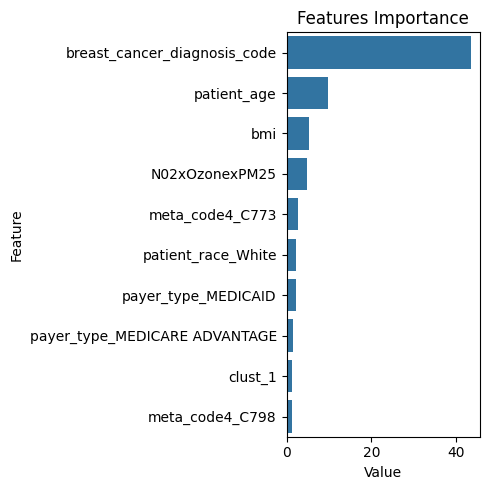

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

### Submission

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions_df1.csv",index=None)

## df2

### Encoding

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf2.columns[tdf2.dtypes=="object"])
cols = [col for col in tdf2.columns if col not in ["patient_id"]]
tdf2[target] = np.nan

# concatenate train and test set
df2 = pd.concat([df2,tdf2[df2.columns]],axis=0)

In [ ]:
# do one-hot encoding for some features
age_cols = list(df2.filter(regex="age").columns)
cols = list(set(cols)-set(age_cols))
income_cols = list(df2.filter(regex="income").columns)
cols = list(set(cols)-set(income_cols))
cols = list(set(cols)-{"breast_cancer_diagnosis_code","N02xOzonexPM25","bmi"})
df2=pd.get_dummies(df2,columns=cols,dtype="int",drop_first=True)
cols

['is_female',
 'metastatic_cancer_diagnosis_code',
 'NO2xPM25xcommute_scaled',
 'patient_race',
 'Division',
 'patient_zip3',
 'clust',
 'Region',
 'breast_cancer_diagnosis_desc',
 'patient_state',
 'payer_type']

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df2[col]=le.fit_transform(df2[col]).astype("int")
        print(col)
    except:
        continue

breast_cancer_diagnosis_code


In [ ]:
tdf2=df2[df2[target].isna()]
df2=df2[df2[target].notna()]
len(df2),len(tdf2)

(12906, 5792)

### Modelling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
# ▶ XGBoost
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df2.columns)-set(drop_cols))

# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# use stacking method, define meta model
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df2, df2[target])):
    df2x, efx = df2.iloc[train_index], df2.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(df2x[cols].values, df2x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(df2x[cols].values, df2x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(df2x[cols].values, df2x[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf2["pred1"] = modela.predict_proba(tdf2[cols].values)[:,1]
    tdf2["pred2"] = modelb.predict_proba(tdf2[cols].values)[:,1]
    tdf2["pred1b"] = model2a.predict_proba(tdf2[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf2["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf2[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf2],axis=0)

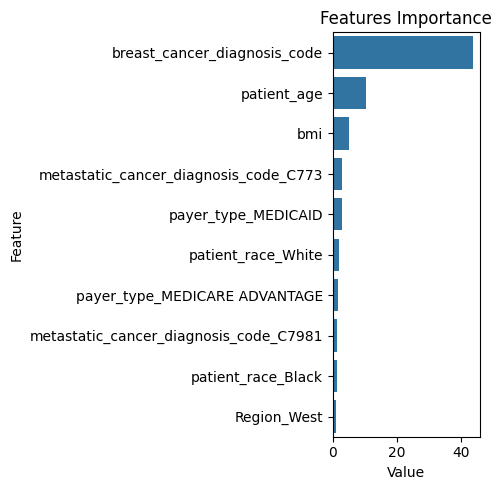

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

### Submission

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions_df2.csv",index=None)

## df3

### Encoding

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf3.columns[tdf3.dtypes=="object"])
cols = [col for col in tdf3.columns if col not in ["patient_id"]]
tdf3[target] = np.nan

# concatenate train and test set
df3 = pd.concat([df3,tdf3[df3.columns]],axis=0)

In [ ]:
# do one-hot encoding for some features
age_cols = list(df3.filter(regex="age").columns)
cols = list(set(cols)-set(age_cols))
income_cols = list(df3.filter(regex="income").columns)
cols = list(set(cols)-set(income_cols))
cols = list(set(cols)-{"breast_cancer_diagnosis_code","N02xOzonexPM25","bmi"})
df3=pd.get_dummies(df3,columns=cols,dtype="int",drop_first=True)
cols

['is_female',
 'metastatic_cancer_diagnosis_code',
 'clust',
 'patient_race',
 'Region',
 'breast_cancer_diagnosis_desc',
 'patient_state',
 'payer_type']

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df3[col]=le.fit_transform(df3[col]).astype("int")
        print(col)
    except:
        continue

breast_cancer_diagnosis_code


In [ ]:
tdf3=df3[df3[target].isna()]
df3=df3[df3[target].notna()]
len(df3),len(tdf3)

(12906, 5792)

### Modelling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
# ▶ XGBoost
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df3.columns)-set(drop_cols))

# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# use stacking method, define meta model
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df3, df3[target])):
    df3x, efx = df3.iloc[train_index], df3.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(df3x[cols].values, df3x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(df3x[cols].values, df3x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(df3x[cols].values, df3x[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf3["pred1"] = modela.predict_proba(tdf3[cols].values)[:,1]
    tdf3["pred2"] = modelb.predict_proba(tdf3[cols].values)[:,1]
    tdf3["pred1b"] = model2a.predict_proba(tdf3[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf3["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf3[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf3],axis=0)

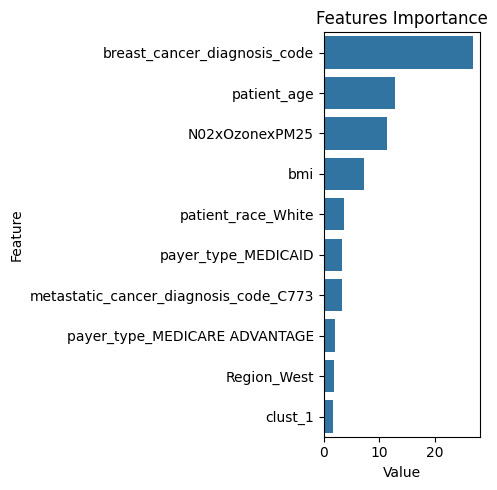

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

### Submission

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions_df3.csv",index=None)

## df4

### Encoding

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf4.columns[tdf4.dtypes=="object"])
cols = [col for col in tdf4.columns if col not in ["patient_id"]]
tdf4[target] = np.nan

# concatenate train and test set
df4 = pd.concat([df4,tdf4[df4.columns]],axis=0)

In [ ]:
# do one-hot encoding for some features
age_cols = list(df4.filter(regex="age").columns)
cols = list(set(cols)-set(age_cols))
income_cols = list(df4.filter(regex="income").columns)
cols = list(set(cols)-set(income_cols))
cols = list(set(cols)-{"breast_cancer_diagnosis_code","N02xOzonexPM25","bmi"})
df4=pd.get_dummies(df4,columns=cols,dtype="int",drop_first=True)
cols

['is_female',
 'breast_cancer_diagnosis_code_mapped',
 'metastatic_cancer_diagnosis_code',
 'clust',
 'patient_race',
 'Division',
 'patient_zip3',
 'Region',
 'breast_cancer_diagnosis_desc_mapped',
 'patient_state',
 'payer_type']

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df4[col]=le.fit_transform(df4[col]).astype("int")
        print(col)
    except:
        continue

In [ ]:
tdf4=df4[df4[target].isna()]
df4=df4[df4[target].notna()]
len(df4),len(tdf4)

(12906, 5792)

### Modelling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
# ▶ XGBoost
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df4.columns)-set(drop_cols))

# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# use stacking method, define meta model
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df4, df4[target])):
    df4x, efx = df4.iloc[train_index], df4.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(df4x[cols].values, df4x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(df4x[cols].values, df4x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(df4x[cols].values, df4x[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf4["pred1"] = modela.predict_proba(tdf4[cols].values)[:,1]
    tdf4["pred2"] = modelb.predict_proba(tdf4[cols].values)[:,1]
    tdf4["pred1b"] = model2a.predict_proba(tdf4[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf4["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf4[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf4],axis=0)

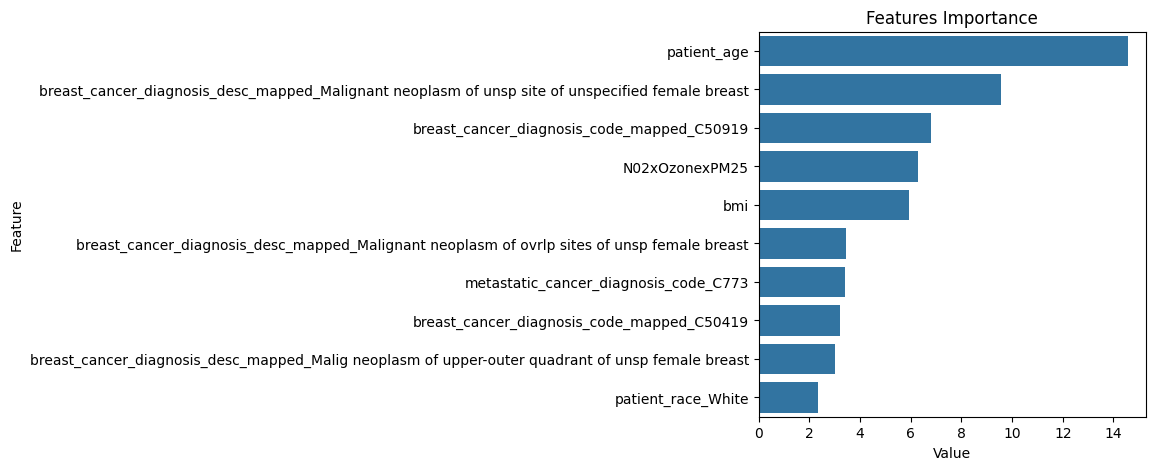

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

### Submission

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions_df4.csv",index=None)

## df5

### Encoding

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf5.columns[tdf5.dtypes=="object"])
cols = [col for col in tdf5.columns if col not in ["patient_id"]]
tdf5[target] = np.nan

# concatenate train and test set
df5 = pd.concat([df5,tdf5[df5.columns]],axis=0)

In [ ]:
# do one-hot encoding for some features
age_cols = list(df5.filter(regex="age").columns)
cols = list(set(cols)-set(age_cols))
income_cols = list(df5.filter(regex="income").columns)
cols = list(set(cols)-set(income_cols))
cols = list(set(cols)-{"breast_cancer_diagnosis_code","N02xOzonexPM25","bmi"})
df5=pd.get_dummies(df5,columns=cols,dtype="int",drop_first=True)
cols

['is_female',
 'metastatic_cancer_diagnosis_code',
 'tumor_site',
 'clust',
 'patient_race',
 'Division',
 'patient_zip3',
 'Region',
 'patient_state',
 'payer_type']

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df5[col]=le.fit_transform(df5[col]).astype("int")
        print(col)
    except:
        continue

In [ ]:
tdf5=df5[df5[target].isna()]
df5=df5[df5[target].notna()]
len(df5),len(tdf5)

(12906, 5792)

### Modelling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
# ▶ XGBoost
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df5.columns)-set(drop_cols))

# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# use stacking method, define meta model
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df5, df5[target])):
    df5x, efx = df5.iloc[train_index], df5.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(df5x[cols].values, df5x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(df5x[cols].values, df5x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(df5x[cols].values, df5x[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf5["pred1"] = modela.predict_proba(tdf5[cols].values)[:,1]
    tdf5["pred2"] = modelb.predict_proba(tdf5[cols].values)[:,1]
    tdf5["pred1b"] = model2a.predict_proba(tdf5[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf5["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf5[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf5],axis=0)

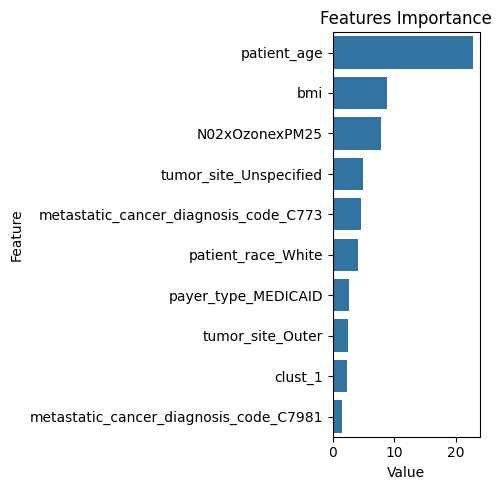

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

### Submission

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions_df5.csv",index=None)

## df6

### Encoding

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf6.columns[tdf6.dtypes=="object"])
cols = [col for col in tdf6.columns if col not in ["patient_id"]]
tdf6[target] = np.nan

# concatenate train and test set
df6 = pd.concat([df6,tdf6[df6.columns]],axis=0)

In [ ]:
# do one-hot encoding for some features
age_cols = list(df6.filter(regex="age").columns)
cols = list(set(cols)-set(age_cols))
income_cols = list(df6.filter(regex="income").columns)
cols = list(set(cols)-set(income_cols))
cols = list(set(cols)-{"breast_cancer_diagnosis_code","N02xOzonexPM25","bmi"})
df6=pd.get_dummies(df6,columns=cols,dtype="int",drop_first=True)
cols

['is_female',
 'metastatic_cancer_diagnosis_code',
 'tumor_site',
 'clust',
 'patient_race',
 'Division',
 'patient_zip3',
 'Region',
 'patient_state',
 'payer_type']

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df5[col]=le.fit_transform(df5[col]).astype("int")
        print(col)
    except:
        continue

In [ ]:
tdf6=df6[df6[target].isna()]
df6=df6[df6[target].notna()]
len(df6),len(tdf6)

(12906, 5792)

### Modelling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
# ▶ XGBoost
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df6.columns)-set(drop_cols))

# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# use stacking method, define meta model
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df6, df6[target])):
    df6x, efx = df6.iloc[train_index], df6.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(df6x[cols].values, df6x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(df6x[cols].values, df6x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(df6x[cols].values, df6x[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf6["pred1"] = modela.predict_proba(tdf6[cols].values)[:,1]
    tdf6["pred2"] = modelb.predict_proba(tdf6[cols].values)[:,1]
    tdf6["pred1b"] = model2a.predict_proba(tdf6[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf6["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf6[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf6],axis=0)

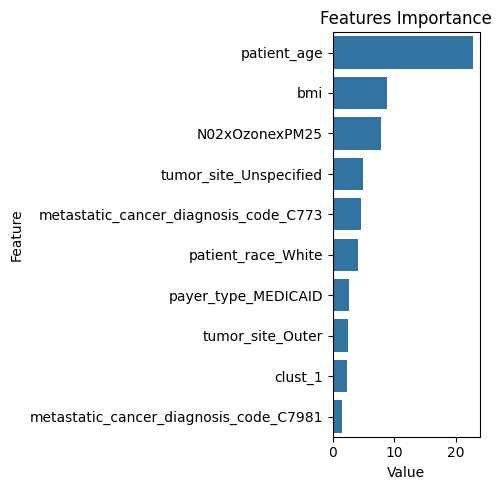

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

### Submission

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions_df6.csv",index=None)

## df8

### Encoding

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf8.columns[tdf8.dtypes=="object"])
cols = [col for col in tdf8.columns if col not in ["patient_id"]]
tdf8[target] = np.nan

# concatenate train and test set
df8 = pd.concat([df8,tdf8[df8.columns]],axis=0)

In [ ]:
# do one-hot encoding for some features
age_cols = list(df8.filter(regex="age").columns)
cols = list(set(cols)-set(age_cols))
income_cols = list(df8.filter(regex="income").columns)
cols = list(set(cols)-set(income_cols))
cols = list(set(cols)-{"breast_cancer_diagnosis_code","N02xOzonexPM25","bmi"})
df8=pd.get_dummies(df8,columns=cols,dtype="int",drop_first=True)
cols

['is_female',
 'metastatic_cancer_diagnosis_code',
 'tumor_site',
 'clust',
 'patient_race',
 'Division',
 'patient_zip3',
 'Region',
 'tumor_site2',
 'patient_state',
 'payer_type']

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df8[col]=le.fit_transform(df8[col]).astype("int")
        print(col)
    except:
        continue

In [ ]:
tdf8=df8[df8[target].isna()]
df8=df8[df8[target].notna()]
len(df8),len(tdf8)

(12906, 5792)

### Modelling

In [ ]:
# ▶ CatBoost
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
# ▶ RandomForest
modelb = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
# ▶ XGBoost
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df8.columns)-set(drop_cols))

# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# use stacking method, define meta model
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df8, df8[target])):
    df8x, efx = df8.iloc[train_index], df8.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(df8x[cols].values, df8x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(df8x[cols].values, df8x[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(df8x[cols].values, df8x[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf8["pred1"] = modela.predict_proba(tdf8[cols].values)[:,1]
    tdf8["pred2"] = modelb.predict_proba(tdf8[cols].values)[:,1]
    tdf8["pred1b"] = model2a.predict_proba(tdf8[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf8["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf8[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf8],axis=0)

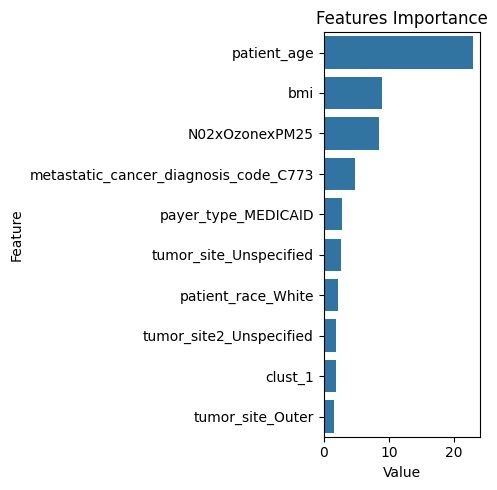

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

### Submission

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions_df8.csv",index=None)

- # 버리는 코드

### patien_race의 Other 인종의 유방암 종양 위치 분포 확률 구할 때

In [ ]:
#### 아이디어1 잘못 구함 : Unspecified와 Overlapping 위치의 경우 tumor_site2의 6개의 종양 위치 확률과는 독립적인 케이스이므로 확률을 tumor_site2의 모든 범주에 대한 비율로 구하면 안 됨
#### 아이디어2 잘못 구함 : Other외의 인종별 유방암 종양 위치 분포 비율의 평균을 이용함 (내가 부탁한 건 논문에서의 확률값 평균이었음)


# 1. 사전 정의된 종양 부위와 주요 인종
tumor_sites = ['Central', 'Upper-inner', 'Lower-inner', 'Upper-outer', 'Lower-outer', 'Axillary tail', 'Unspecified', 'Overlapping']
main_races = ['White', 'Black', 'Asian/PI', 'Hispanic']

# 2. 데이터 필터링
df_filtered = df[df['tumor_site2'].isin(tumor_sites)]
other_data = df_filtered[df_filtered['patient_race'] == 'Other']
n_other = len(other_data)

# 3. 아이디어 1: Other 인종 실제 분포
empirical_dist = (
    other_data['tumor_site2']
    .value_counts(normalize=True)
    .reindex(tumor_sites, fill_value=0)
)

# 4. 아이디어 2: 주요 인종 평균 분포
mean_dist = (
    df_filtered[df_filtered['patient_race'].isin(main_races)]
    .groupby('patient_race')['tumor_site2']
    .value_counts(normalize=True)
    .unstack(fill_value=0)[tumor_sites]
    .mean()
)

# 5. 아이디어 3: 혼합 분포 (가중치 0.5)
w = 0.5
hybrid_dist = w * empirical_dist + (1 - w) * mean_dist

# 6. 결과 정리
result_df = pd.DataFrame({
    'Tumor Site': tumor_sites,
    'Idea 1: Empirical (%)': (empirical_dist * 100).round(2),
    'Idea 2: Avg 4 Races (%)': (mean_dist * 100).round(2),
    'Idea 3: Hybrid (50/50) (%)': (hybrid_dist * 100).round(2)
})

# 7. 출력
print(f"✅ 'Other' 인종 샘플 수: {n_other}명\n")
print("🎯 유방암 종양 위치별 확률 분포 (모든 방법 비교):")
print(result_df.to_string(index=False))


✅ 'Other' 인종 샘플 수: 681명

🎯 유방암 종양 위치별 확률 분포 (모든 방법 비교):
   Tumor Site  Idea 1: Empirical (%)  Idea 2: Avg 4 Races (%)  Idea 3: Hybrid (50/50) (%)
      Central                   6.75                     5.68                        6.21
  Upper-inner                   5.58                     4.89                        5.23
  Lower-inner                   2.64                     2.61                        2.62
  Upper-outer                  20.70                    16.13                       18.42
  Lower-outer                   4.26                     2.99                        3.62
Axillary tail                   0.29                     0.50                        0.40
  Unspecified                  49.93                    58.07                       54.00
  Overlapping                   9.84                     9.15                        9.49
